In [1]:
%cd ..

/home/hsc/Projects/personal/disertation


In [2]:
# TODO: write utilities to push the repo to github - clone it on kaggle - then import the package in here

In [3]:
import pandas as pd

In [4]:
from mts.utils.core import collect_classvars

In [28]:
from dataclasses import dataclass
from typing import ClassVar


@collect_classvars
@dataclass
class TrainColumns:
    DATASET: ClassVar[str] = "dataset"
    SCENE: ClassVar[str] = "scene"
    IMAGE: ClassVar[str] = "image"
    ROTATION_MATRIX: ClassVar[str] = "rotation_matrix"
    TRANSLATION_VECTOR: ClassVar[str] = "translation_vector"

    @classmethod
    def columns(cls):
        return list(cls.__classvars__.values())


@collect_classvars
@dataclass
class ThreshColumns:
    DATASET: ClassVar[str] = "dataset"
    SCENE: ClassVar[str] = "scene"
    THRESHOLDS: ClassVar[str] = "thresholds"

    @classmethod
    def columns(cls):
        return list(cls.__classvars__.values())

In [6]:
from pathlib import Path

In [7]:
DATA_DIRPATH = Path("./data")
TRAIN_DATA_DIRPATH = DATA_DIRPATH / "train"
TEST_DATA_DIRPATH = DATA_DIRPATH / "test"
TRAIN_CSV_FILEPATH = DATA_DIRPATH / "train_labels.csv"
THRESH_CSV_FILEPATH = DATA_DIRPATH / "train_thresholds.csv"

In [8]:
train_df = pd.read_csv(
    TRAIN_CSV_FILEPATH,
    header=0,
    names=TrainColumns.columns(),
)
thresh_df = pd.read_csv(
    THRESH_CSV_FILEPATH,
    header=0,
    names=ThreshColumns.columns(),
)

In [9]:
train_df[TrainColumns.SCENE].unique()

array(['fountain', 'bike', 'chairs', 'outliers', 'dioscuri', 'cyprus',
       'wall', 'church', 'kyiv-puppet-theater', 'baalshamin', 'lizard',
       'pond', 'british_museum', 'buckingham_palace', 'brandenburg_gate',
       'piazza_san_marco', 'grand_place_brussels', 'trevi_fountain',
       'sacre_coeur', 'taj_mahal', 'st_pauls_cathedral',
       'st_peters_square', 'peach', 'vineyard_split_2',
       'vineyard_split_3', 'vineyard_split_1', 'ET', 'another_ET',
       'stairs_split_1', 'stairs_split_2'], dtype=object)

In [10]:
train_df[train_df[TrainColumns.SCENE] == "bike"]

,dataset,scene,image,rotation_matrix,translation_vector
23,imc2023_haiper,bike,bike_image_119.png,0.341392766;0.813514561;-0.470791927;0.7000409...,-0.100077945;-2.544833204;4.041704877
24,imc2023_haiper,bike,bike_image_115.png,0.390404366;0.163671893;-0.905977893;0.8861032...,0.829697550;-2.348041794;3.472508100
25,imc2023_haiper,bike,bike_image_038.png,-0.440758751;-0.614134480;0.654653011;0.867590...,-0.806161998;-1.361491410;2.575947894
26,imc2023_haiper,bike,bike_image_049.png,-0.461507078;-0.037215313;0.886355593;0.804080...,-0.050292370;-2.095335108;3.128109738
27,imc2023_haiper,bike,bike_image_139.png,0.454847580;0.533125630;-0.713365784;0.3913771...,1.086957983;-1.559403473;3.044106079
28,imc2023_haiper,bike,bike_image_029.png,-0.303794298;-0.780428110;0.546480548;0.914537...,-0.774379505;-2.406362247;4.203909144
29,imc2023_haiper,bike,bike_image_150.png,0.574971611;-0.279231423;-0.769049711;0.809566...,0.426737871;-1.868801598;2.797678231
30,imc2023_haiper,bike,bike_image_137.png,0.224252446;0.868784308;-0.441502738;0.5321296...,0.784761582;-0.256854640;3.378845297
31,imc2023_haiper,bike,bike_image_004.png,-0.044408637;-0.994362210;0.096289498;0.998633...,-0.196067220;-1.720151463;2.903829461
32,imc2023_haiper,bike,bike_image_128.png,-0.217724885;0.694914688;0.685338932;0.6038737...,-1.109435203;-2.545644986;4.578881333


In [11]:
thresh_df[thresh_df[TrainColumns.SCENE] == "bike"]

,dataset,scene,thresholds
8,imc2023_haiper,bike,0;0;0.001;0.025;0.05;0.1


In [12]:
import torch

In [13]:
cuda_device = torch.device("cuda:0")

In [14]:
cuda_device

device(type='cuda', index=0)

In [15]:
torch.cuda.is_available()

True

In [16]:
train_df.groupby(TrainColumns.DATASET).apply(lambda x: len(x))

/tmp/ipykernel_8411/3275404467.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train_df.groupby(TrainColumns.DATASET).apply(lambda x: len(x))


dataset
ETs                                   22
amy_gardens                          200
fbk_vineyard                         163
imc2023_haiper                        54
imc2023_heritage                     209
imc2023_theather_imc2024_church       76
imc2024_dioscuri_baalshamin          138
imc2024_lizard_pond                  214
pt_brandenburg_british_buckingham    225
pt_piazzasanmarco_grandplace         168
pt_sacrecoeur_trevi_tajmahal         225
pt_stpeters_stpauls                  200
stairs                                51
dtype: int64

In [17]:
train_df.groupby([TrainColumns.DATASET, TrainColumns.SCENE]).apply(
    lambda x: len(x),
    include_groups=False,
)

dataset                            scene               
ETs                                ET                        9
                                   another_ET               10
                                   outliers                  3
amy_gardens                        peach                   200
fbk_vineyard                       vineyard_split_1         43
                                   vineyard_split_2         35
                                   vineyard_split_3         85
imc2023_haiper                     bike                     15
                                   chairs                   16
                                   fountain                 23
imc2023_heritage                   cyprus                   30
                                   dioscuri                 75
                                   outliers                 61
                                   wall                     43
imc2023_theather_imc2024_church    church                   50

In [18]:
train_df[train_df[TrainColumns.SCENE] == "outliers"].groupby(
    TrainColumns.DATASET
).apply(len, include_groups=False)

dataset
ETs                             3
imc2023_heritage               61
imc2024_dioscuri_baalshamin    24
imc2024_lizard_pond            34
dtype: int64

In [19]:
train_df[TrainColumns.SCENE].unique()

array(['fountain', 'bike', 'chairs', 'outliers', 'dioscuri', 'cyprus',
       'wall', 'church', 'kyiv-puppet-theater', 'baalshamin', 'lizard',
       'pond', 'british_museum', 'buckingham_palace', 'brandenburg_gate',
       'piazza_san_marco', 'grand_place_brussels', 'trevi_fountain',
       'sacre_coeur', 'taj_mahal', 'st_pauls_cathedral',
       'st_peters_square', 'peach', 'vineyard_split_2',
       'vineyard_split_3', 'vineyard_split_1', 'ET', 'another_ET',
       'stairs_split_1', 'stairs_split_2'], dtype=object)

In [20]:
cyprus_df = train_df[train_df[TrainColumns.SCENE] == 'vineyard_split_3']

In [21]:
import numpy as np


def load_images(df: pd.DataFrame) -> np.ndarray:
    pass

In [22]:
from PIL import Image
import matplotlib.pyplot as plt


def display_images(images_filepaths: list[str | Path]) -> None:
    n_cols = 4
    n_images = len(images_filepaths)
    n_rows = (n_images + n_cols - 1) // n_cols

    plt.figure(figsize=(16, 4 * n_rows))
    images = []

    for i, path in enumerate(images_filepaths):
        img0 = Image.open(path)
        img = img0.resize((512, 512))
        images.append(img)

        plt.subplot(n_rows, n_cols, i + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"Image {i+1}")

    plt.tight_layout()
    plt.show()

In [23]:
selected_scene = 'fountain'
scene_df = train_df.groupby(TrainColumns.SCENE).get_group(selected_scene)

In [24]:
def make_image_filepaths(df: pd.DataFrame) -> list[str]:
    images_filepaths = (
        str(TRAIN_DATA_DIRPATH)
        + "/"
        + df[TrainColumns.DATASET]
        + "/"
        + df[TrainColumns.IMAGE]
    ).tolist()
    return images_filepaths

In [26]:
image_filepaths = make_image_filepaths(train_df)

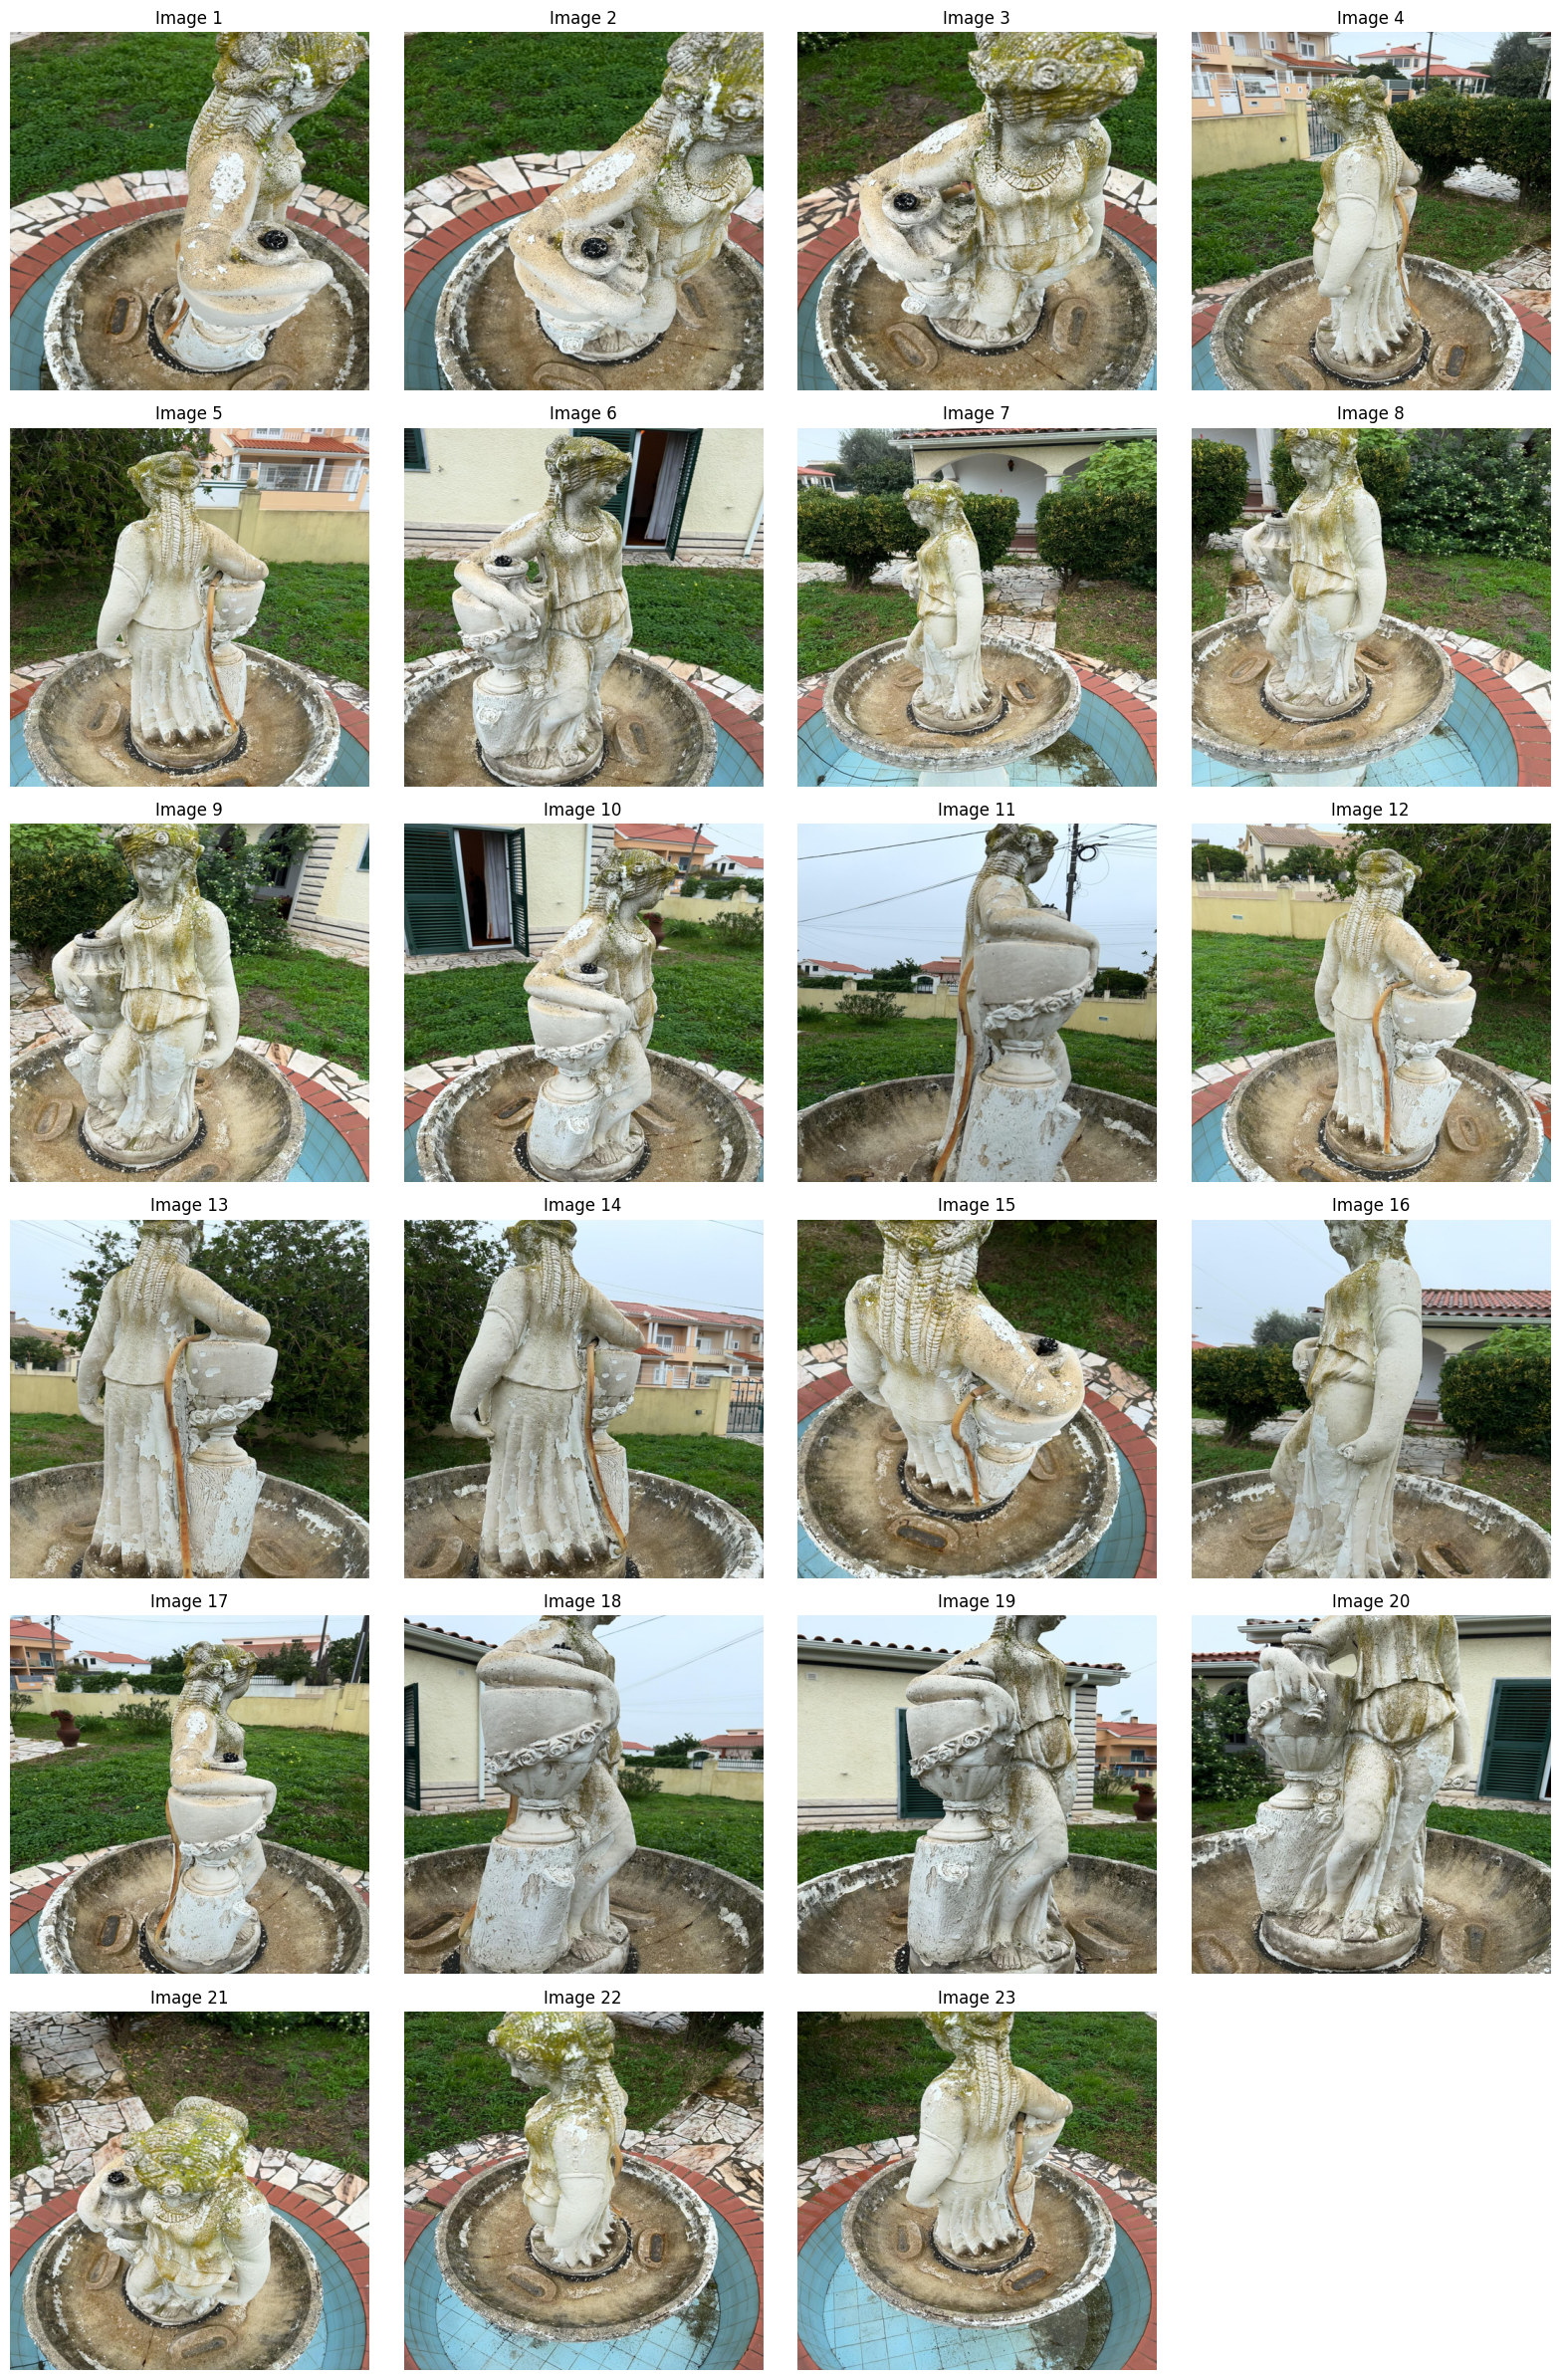

In [27]:
display_images(make_image_filepaths(scene_df))

In [29]:
from mts.core.embeddings.base import extract_embeddings
from mts.core.embeddings.vlad import NetVladEmbedding

/home/hsc/Projects/personal/disertation/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [30]:
netvlad_embedder = NetVladEmbedding()

In [31]:
CPU = torch.device("cpu")

In [32]:
train_df[TrainColumns.SCENE].unique()

array(['fountain', 'bike', 'chairs', 'outliers', 'dioscuri', 'cyprus',
       'wall', 'church', 'kyiv-puppet-theater', 'baalshamin', 'lizard',
       'pond', 'british_museum', 'buckingham_palace', 'brandenburg_gate',
       'piazza_san_marco', 'grand_place_brussels', 'trevi_fountain',
       'sacre_coeur', 'taj_mahal', 'st_pauls_cathedral',
       'st_peters_square', 'peach', 'vineyard_split_2',
       'vineyard_split_3', 'vineyard_split_1', 'ET', 'another_ET',
       'stairs_split_1', 'stairs_split_2'], dtype=object)

In [33]:
img = Image.open(image_filepaths[0])

In [34]:
from tqdm.auto import tqdm

sizes = [Image.open(image_fp).size for image_fp in tqdm(image_filepaths)]

  0%|          | 0/1945 [00:00<?, ?it/s]

100%|██████████| 1945/1945 [00:00<00:00, 3677.09it/s]


In [35]:
from plotly import express as px

In [36]:
sizes = np.array(sizes)

In [37]:
px.scatter(x=sizes[:, 0], y=sizes[:, 1])

In [38]:
CUDA0 = torch.device("cuda:0")

In [39]:
image_filepaths = make_image_filepaths(scene_df)

In [40]:
with torch.autocast(device_type="cuda"):
    netvlad_embedder = netvlad_embedder.to(CUDA0)
    embeddings = extract_embeddings(netvlad_embedder, image_filepaths)

  0%|          | 0/23 [00:00<?, ?it/s]

100%|██████████| 23/23 [00:11<00:00,  1.92it/s]


In [41]:
embeddings_t = torch.stack(embeddings)

In [42]:
def normalize(array: np.ndarray) -> np.ndarray:
    max_value = np.max(array)
    min_value = np.min(array)
    value_range = max_value - min_value
    return (array - min_value) / value_range

In [43]:
import hloc
import hloc.extractors.aliked
from hloc.extract_features import confs

In [45]:
dist_map = torch.cdist(embeddings_t, embeddings_t)
norm_dist_map = normalize(dist_map.numpy())

In [46]:
import more_itertools as mit

In [47]:
from mts.utils.pair import generate_exhaustive

In [48]:
xs, ys = np.where(norm_dist_map < 0.85)
indices_mask = xs > ys

In [49]:
indices = np.stack([xs[indices_mask], ys[indices_mask]]).T

In [50]:
norm_dist_map[norm_dist_map < 0.8] = 0

In [51]:
from hloc.matchers import nearest_neighbor

In [52]:
nn_matcher = nearest_neighbor.NearestNeighbor({})

In [55]:
px.imshow(dist_map)

In [57]:
torch.cuda.empty_cache()

In [56]:
netvlad_embedder = netvlad_embedder.to(CPU)

In [58]:
from mts.utils.image import imread_rgb
from mts.utils.torchx import to_torch_format
from mts.helpers.torch.nn import get

In [59]:
module_info = get(aliked)

In [60]:
import more_itertools as mit

In [61]:
from mts.helpers.torch.tensor import to

In [62]:
import math

In [74]:
aliked = hloc.extractors.aliked.ALIKED(confs["aliked-n16"]["model"] | {"max_num_keypoints": 2048})
aliked = aliked.to(CUDA0)

In [75]:
extractions = []
batch_size = 1
batches = math.ceil(len(image_filepaths) / batch_size)
with torch.no_grad():
    for image_filepath_chunk in tqdm(
        mit.chunked(image_filepaths, batch_size),
        total=batches,
        desc="Compute descriptors",
    ):
        img_batch = np.stack(
            [imread_rgb(image_filepath) for image_filepath in image_filepath_chunk]
        )
        extraction = aliked(
            {
                "image": to_torch_format(img_batch).to(
                    device=module_info.device, dtype=module_info.dtype
                )
            },
        )
        extractions.append(to(extraction, device=CPU))

Compute descriptors: 100%|██████████| 23/23 [00:04<00:00,  4.97it/s]


In [103]:
from mts.helpers.colmap.database import COLMAPDatabase


colmap_db = COLMAPDatabase("text.db")
colmap_db.create_tables()

In [76]:
pairs_indices = generate_exhaustive(len(image_filepaths))

In [81]:
matches_map = {}
for index_from, index_to in tqdm(pairs_indices):
    kp_from, kp_to = extractions[index_from], extractions[index_to]

    match = nn_matcher(
        {
            "descriptors0": torch.unsqueeze(kp_from["descriptors"][0], 0),
            "descriptors1": torch.unsqueeze(kp_to["descriptors"][0], 0),
        }
    )

    matches = torch.stack((torch.arange(len(match["matches0"][0])), match["matches0"][0])).T
    matches = matches[matches[..., 1] != -1]
    matches_map[index_from, index_to] = matches


100%|██████████| 253/253 [00:01<00:00, 149.20it/s]


In [82]:
for image_filepath in image_filepaths:
    pass

In [84]:
class CameraModel:
    SIMPLE_PINHOLE = 'simple-pinhole'
    PINHOLE = 'pinhole'
    SIMPLE_RADIAL = 'simple-radial'
    OPENCV = 'opencv'

array([[ 771.9998 ,  677.03107],
       [1043.2872 , 1089.6901 ],
       [ 568.064  ,  145.06953],
       ...,
       [ 546.1312 , 1062.0638 ],
       [ 652.61505, 1275.1737 ],
       [ 361.47308, 1222.3251 ]], shape=(2048, 2), dtype=float32)

In [96]:

keypoints = extraction["keypoints"][0].numpy()

In [97]:
keypoints.tobytes()

b'\xfd\xff@D\xfdA)D1i\x82D\x156\x88D\x19\x04\x0eD\xcd\x11\x11C \xa1\xedC\xf5E\x94D8\xf3\xfaC\xa0J\xb2DoP=D\xa4\xf8~D\xc0\x1e\xa8D\x87=\xbaD\\U%D\xce@\xb0D\xd9\xa1\x15DR4\xb3D\x0c.fD\xea\x00\xb3D\x19\xc4 D\xce<\xddD\xf3 \x9bD\xc6\xb4\x95B\xf4\xc5AD\xb5:\xe9Di\xe1\x8cD\xd5(3D\x08\x12\xe4C|d\xd3D\xb1g,D&d\xa2D\xfbG4D\xfcj\xa0D\x0b\xb5\xc7C\xc2\x9f\xa8D\xe4ZOD\xdb\xba\x9cDo?\xa1D\x9b\xc5>C\x16\x9d<D"\xe1\x9eD\xf7\xf0\xe5C0\xa3\x8bDuDvD\xa8a\x8dD\xda@QD\x06\xa1\xa5D\xfc\x15SD\xd2*\rD\xf6TYDF\x1d\x9fD\xb5\xae\xf7C\x8f*\xb4D7\xaa\x88D\xf0\xac\x89D\xb9a\x8dC\xc1\xb1vD\x91\xbf\xa0D\x8b\x88\xd3B\x9e\xc2wD6$\x9bD\x99D\x12D\xcc\xbf\x80D\x15A#Dq\xa9\xdfD\x90\xa7uD\xc3\x1c\x91Di\x8d2Dfv\xa3D\rI\x89D\x04A\x8bD!\xbb@D\xb5/`DY\xaeSD\x97\xc7"C\xbd\xff\x83D\xd6LYD\xb2\xbf\xa6Dx{\xe2Dm\x87BD\xf9\x06 D\x16\x9d\xddCK|\x1aDP\xce\x83D(\xbd\xcfD\xd9\x13\x10D\x0b\xe9\xbaD\xdc\xc0\xa7D\x8fv\tD\x8eD\x84D1\xff\x84D\x80;\x86D\xb9t\xd1D\x86K;D\xfa\x96rD\xeb\xa2\x10D\x02+\xcfD\x01F\x9fD"\xed\xb0CrZ\xddC\xef[\x90D7\x7

In [99]:
np.__version__ > '1.19.0'

True

In [ ]:
keypoints

In [ ]:
from mts.helpers.colmap.h5_to_db import create_camera

filepaths_to_image_id = {}

for extraction, image_filepath in zip(extractions, image_filepaths):
    camera_id = create_camera(colmap_db, image_filepath, CameraModel.SIMPLE_RADIAL)
    image_id = colmap_db.add_image(image_filepath, camera_id=camera_id)
    keypoints = extraction["keypoints"][0].numpy()
    descriptors = extraction["descriptors"][0].numpy()
    colmap_db.add_descriptors(image_id, descriptors)
    colmap_db.add_keypoints(image_id, keypoints)
    filepaths_to_image_id[image_filepath] = image_id


for (from_idx, to_idx), matches in matches_map.items():
    st_image_id = filepaths_to_image_id[image_filepaths[from_idx]]
    nd_image_id = filepaths_to_image_id[image_filepaths[to_idx]]
    colmap_db.add_matches(st_image_id, nd_image_id, matches.numpy())

colmap_db.commit()

In [121]:
matches.numpy().dtype

dtype('int64')

IntegrityError: UNIQUE constraint failed: matches.pair_id

In [113]:
to_idx

22

In [109]:
from_idx

(21, 22)

22

In [90]:
image_filepath

'data/train/imc2023_haiper/fountain_image_116.png'

In [83]:
image_filepath

'data/train/imc2023_haiper/fountain_image_129.png'

In [ ]:
import torch
import gc

for obj in gc.get_objects():
    try:
        if torch.is_tensor(obj) or (hasattr(obj, "data") and torch.is_tensor(obj.data)):
            print(type(obj), obj.size(), obj.device)

    except:
        pass

<class 'torch.Tensor'> torch.Size([25, 2]) cuda:0
<class 'torch.Tensor'> torch.Size([15053]) cpu
<class 'torch.Tensor'> torch.Size([128, 15053]) cpu
<class 'torch.Tensor'> torch.Size([16414]) cpu
<class 'torch.Tensor'> torch.Size([128, 16414]) cpu
<class 'torch.Tensor'> torch.Size([17360]) cpu
<class 'torch.Tensor'> torch.Size([128, 17360]) cpu
<class 'torch.Tensor'> torch.Size([17710]) cpu
<class 'torch.Tensor'> torch.Size([128, 17710]) cpu
<class 'torch.Tensor'> torch.Size([18323]) cpu
<class 'torch.Tensor'> torch.Size([128, 18323]) cpu
<class 'torch.Tensor'> torch.Size([18884]) cpu
<class 'torch.Tensor'> torch.Size([128, 18884]) cpu
<class 'torch.Tensor'> torch.Size([19159]) cpu
<class 'torch.Tensor'> torch.Size([128, 19159]) cpu
<class 'torch.Tensor'> torch.Size([19240]) cpu
<class 'torch.Tensor'> torch.Size([128, 19240]) cpu
<class 'torch.Tensor'> torch.Size([19228]) cpu
<class 'torch.Tensor'> torch.Size([128, 19228]) cpu
<class 'torch.Tensor'> torch.Size([17348]) cpu
<class 'torc

/home/hsc/Projects/personal/disertation/.venv/lib/python3.11/site-packages/torch/__init__.py:1136: FutureWarning:

`torch.distributed.reduce_op` is deprecated, please use `torch.distributed.ReduceOp` instead

/tmp/ipykernel_11949/2591448762.py:6: FutureWarning:

`torch.distributed.reduce_op` is deprecated, please use `torch.distributed.ReduceOp` instead

